# Kaş ROI Çıkarma Pipeline'ı — Google Colab

Bu notebook, deepfake veri hazırlama sürecinde yüz framelerinden **iki kaşı aynı görüntüde içeren, ham, renkli ve yeniden boyutlandırılmamış ROI** üretir.

## Teknik yaklaşım

- **Landmark yöntemi:** MediaPipe Tasks API `FaceLandmarker`
- **ROI:** Sağ ve sol kaş landmarklarının birleşik bounding box'ı
- **Marginler:** Sabit piksel yerine kaş genişliği ve etkin kaş yüksekliğine bağlı oranlar
- **Göz güvenliği:** Göz merkezleri ROI dışında tutulur; göz landmarklarının ROI içindeki oranı sınırlandırılır
- **Ana çıktı:** Renkli doğal crop; resize, padding, grayscale, filtre, augmentation veya özellik çıkarımı uygulanmaz
- **Resume:** `metadata.csv`, `checkpoint.json`, kaynak ve çıktı SHA-256 doğrulaması
- **Yol güvenliği:** Drive içinde klasör aranmaz; yalnızca verilen tam kaynak ve hedef yollar kullanılır
- **Tam pipeline kilidi:** Preview gözle kontrol edilmeden tam çalışma başlamaz

```text
SOURCE:
/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame

TARGET:
/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş
```

```text
Kaş/
├── fake/
│   ├── train/
│   ├── val/
│   └── test/
├── real/
│   ├── train/
│   ├── val/
│   └── test/
├── run_config.json
├── metadata.csv
├── skipped_or_error.csv
├── checkpoint.json
├── summary.json
├── pipeline.log
└── preview_grid.png
```

In [1]:
# 1) GOOGLE DRIVE MOUNT
from google.colab import drive

drive.mount("/content/drive", force_remount=False)
print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [2]:
# 2) BAĞIMLILIK KURULUMU VE MODEL İNDİRME
# Eski mp.solutions API'si kullanılmaz.
# Colab'ın hazır NumPy, pandas, OpenCV ve görüntüleme paketleri
# gereksiz yere yükseltilmez.

%pip install -q "mediapipe==0.10.30"

from pathlib import Path
from urllib.request import urlopen

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "face_landmarker/face_landmarker/float16/1/face_landmarker.task"
)
MODEL_PATH = Path("/content/face_landmarker.task")

if not MODEL_PATH.exists() or MODEL_PATH.stat().st_size < 1_000_000:
    print("Face Landmarker modeli indiriliyor...")
    payload = urlopen(MODEL_URL, timeout=120).read()
    if len(payload) < 1_000_000:
        raise RuntimeError(
            f"Model dosyası beklenenden küçük: {len(payload):,} bayt"
        )
    temporary = MODEL_PATH.with_name(".face_landmarker.task.tmp")
    temporary.write_bytes(payload)
    temporary.replace(MODEL_PATH)

print("Model:", MODEL_PATH)
print("Boyut:", f"{MODEL_PATH.stat().st_size:,} bayt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.0 MB/s eta 0:00:00
Face Landmarker modeli indiriliyor...
Model: /content/face_landmarker.task
Boyut: 3,758,596 bayt


In [3]:
# 3) IMPORT VE ORTAM DOĞRULAMASI
import hashlib
import io
import json
import logging
import math
import os
import platform
import random
import re
import sys
import tempfile
import time
import uuid

from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple

import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import PIL
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

print("Python:", sys.version)
print("Platform:", platform.platform())
print("MediaPipe:", mp.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
if pd.__version__ != "2.2.2":
    raise RuntimeError(
        "Bu Colab ortamında pandas==2.2.2 bekleniyor; "
        f"bulunan sürüm: {pd.__version__}. "
        "Çalışma zamanını yeniden başlatıp hücreleri baştan çalıştırın."
    )
print("Pillow:", PIL.__version__)

required = [
    hasattr(mp, "tasks"),
    hasattr(vision, "FaceLandmarker"),
    hasattr(vision, "FaceLandmarkerOptions"),
    hasattr(vision, "RunningMode"),
    hasattr(mp_python, "BaseOptions"),
]
if not all(required):
    raise ImportError(
        "MediaPipe Tasks API doğrulanamadı. Runtime'ı yeniden başlatıp "
        "kurulum hücresini tekrar çalıştırın."
    )
if not MODEL_PATH.is_file():
    raise FileNotFoundError(f"Model bulunamadı: {MODEL_PATH}")

print("Tasks API import doğrulaması başarılı.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
MediaPipe: 0.10.30
OpenCV: 5.0.0
NumPy: 2.0.2
Pandas: 2.2.2
Pillow: 11.3.0
Tasks API import doğrulaması başarılı.


In [4]:
# 4) CONFIG

class ConfigurationError(RuntimeError):
    """Güvenli pipeline konfigürasyon hatası."""


class DetectionSkipped(RuntimeError):
    """Şüpheli crop kaydetmeden örneği atlar."""


@dataclass(frozen=True)
class PipelineConfig:
    source_root: Path = Path(
        "/content/drive/MyDrive/AISC DeepFake Çalışmaları/"
        "Deneyler/Deney 1 Frame"
    )
    target_root: Path = Path(
        "/content/drive/MyDrive/AISC DeepFake Çalışmaları/"
        "Deneyler/Nazlıcan/Deney 1/Kaş"
    )
    model_path: Path = Path("/content/face_landmarker.task")
    model_url: str = MODEL_URL

    seed: int = 42
    image_extensions: Tuple[str, ...] = (
        ".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"
    )

    horizontal_margin_ratio: float = 0.075
    top_margin_ratio: float = 0.65
    bottom_margin_ratio: float = 0.22
    brow_height_floor_ratio: float = 0.12
    upper_eyelid_allowance_ratio: float = 0.04

    min_roi_width: int = 48
    min_roi_height: int = 14
    max_eye_landmark_fraction: float = 0.25
    min_pixel_std: float = 2.0
    duplicate_edge_mae_threshold: float = 0.35

    # None iken blur yalnız metadata'ya yazılır, eleme yapılmaz.
    blur_threshold: Optional[float] = None

    # Varsayılan güvenli davranış: hizalama kapalı.
    enable_alignment: bool = False
    min_alignment_degrees: float = 2.0
    max_alignment_degrees: float = 12.0
    alignment_blur_retention_ratio: float = 0.82
    alignment_border_value: Tuple[int, int, int] = (0, 0, 0)

    max_faces_to_detect: int = 2
    min_face_detection_confidence: float = 0.55
    min_face_presence_confidence: float = 0.55
    min_tracking_confidence: float = 0.50

    retry_skipped: bool = False
    retry_errors: bool = True
    verify_output_sha256: bool = True
    metadata_flush_interval: int = 25

    preview_sample_count: int = 24
    preview_tile_width: int = 560
    preview_tile_height: int = 260
    preview_columns: int = 2

    jpeg_quality: int = 95
    png_compression: int = 3

    expected_target_suffix: Tuple[str, ...] = (
        "Deneyler", "Nazlıcan", "Deney 1", "Kaş"
    )

    def serializable(self) -> Dict[str, Any]:
        data = asdict(self)
        data["source_root"] = str(self.source_root)
        data["target_root"] = str(self.target_root)
        data["model_path"] = str(self.model_path)
        data["image_extensions"] = list(self.image_extensions)
        data["expected_target_suffix"] = list(self.expected_target_suffix)
        data["alignment_border_value"] = list(self.alignment_border_value)
        return data


CONFIG = PipelineConfig()
random.seed(CONFIG.seed)
np.random.seed(CONFIG.seed)

print("SOURCE_ROOT =", CONFIG.source_root)
print("TARGET_ROOT =", CONFIG.target_root)
print("Alignment =", CONFIG.enable_alignment)
print("Blur threshold =", CONFIG.blur_threshold)

SOURCE_ROOT = /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame
TARGET_ROOT = /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş
Alignment = False
Blur threshold = None


In [5]:
# 5) PATH GÜVENLİK DOĞRULAMASI

class PathValidator:
    """Verilen tam yolları doğrular; hedef klasörü hiçbir yerde aramaz."""

    CLASS_MAP: Mapping[str, str] = {"Real": "real", "Fake": "fake"}
    SPLITS: Tuple[str, ...] = ("train", "val", "test")

    def __init__(self, config: PipelineConfig) -> None:
        self.config = config

    @staticmethod
    def absolute(path: Path) -> Path:
        return Path(os.path.abspath(os.path.expanduser(str(path))))

    @staticmethod
    def is_below(child: Path, parent: Path) -> bool:
        try:
            child.relative_to(parent)
            return True
        except ValueError:
            return False

    def validate(self) -> None:
        source = self.absolute(self.config.source_root)
        target = self.absolute(self.config.target_root)

        print("\n" + "=" * 90)
        print("SOURCE ROOT:")
        print(f'"{source}"')
        print("\nTARGET ROOT:")
        print(f'"{target}"')
        print("=" * 90)

        if not source.is_dir():
            raise ConfigurationError(
                f"SOURCE_ROOT mevcut bir klasör değil: {source}"
            )
        if not target.is_dir():
            raise ConfigurationError(
                "TARGET_ROOT mevcut değil. Kod başka yerde hedef "
                f"oluşturmayacak: {target}"
            )

        count = len(self.config.expected_target_suffix)
        actual_suffix = tuple(target.parts[-count:])
        if actual_suffix != self.config.expected_target_suffix:
            raise ConfigurationError(
                "TARGET_ROOT yanlış son ekle bitiyor.\n"
                f"Beklenen: {self.config.expected_target_suffix}\n"
                f"Bulunan:  {actual_suffix}"
            )

        if source == target:
            raise ConfigurationError("Kaynak ve hedef aynı olamaz.")
        if self.is_below(target, source):
            raise ConfigurationError(
                "TARGET_ROOT, SOURCE_ROOT altında. İşlem durduruldu."
            )

        for source_class in self.CLASS_MAP:
            for split in self.SPLITS:
                required = source / source_class / split
                if not required.is_dir():
                    raise ConfigurationError(
                        f"Beklenen kaynak split'i yok: {required}"
                    )

        if not self.config.model_path.is_file():
            raise ConfigurationError(
                f"Landmark modeli yok: {self.config.model_path}"
            )

        structure = "\n".join([
            "Kaş/",
            "├── fake/",
            "├── real/",
            "├── run_config.json",
            "├── metadata.csv",
            "├── skipped_or_error.csv",
            "├── checkpoint.json",
            "├── summary.json",
            "├── pipeline.log",
            "└── preview_grid.png",
        ])
        print("\nOUTPUT STRUCTURE:\n" + structure)
        print(
            "\nOutputs will be written only to the exact TARGET path "
            "shown above. No other Nazlıcan or Kaş folder will be "
            "searched or modified."
        )
        print("\nPath güvenlik doğrulaması başarılı.")

    def discover_inputs(self) -> List[Path]:
        source = self.absolute(self.config.source_root)
        files: List[Path] = []
        for source_class in self.CLASS_MAP:
            for split in self.SPLITS:
                split_root = source / source_class / split
                for path in split_root.rglob("*"):
                    if (
                        path.is_file()
                        and path.suffix.lower()
                        in self.config.image_extensions
                    ):
                        absolute = self.absolute(path)
                        if not self.is_below(absolute, source):
                            raise ConfigurationError(
                                f"Kaynak dışına çıkan yol: {path}"
                            )
                        files.append(absolute)
        return sorted(files, key=lambda p: p.as_posix().lower())

    def parse(self, input_path: Path) -> Tuple[str, str, Path]:
        source = self.absolute(self.config.source_root)
        relative = self.absolute(input_path).relative_to(source)
        if len(relative.parts) < 3:
            raise ConfigurationError(
                f"Beklenmeyen kaynak yolu: {input_path}"
            )
        source_class, split = relative.parts[0], relative.parts[1]
        if source_class not in self.CLASS_MAP:
            raise ConfigurationError(
                f"Geçersiz sınıf klasörü: {source_class}"
            )
        if split not in self.SPLITS:
            raise ConfigurationError(f"Geçersiz split: {split}")
        return (
            self.CLASS_MAP[source_class],
            split,
            Path(*relative.parts[2:]),
        )

    def output_path_for(self, input_path: Path) -> Path:
        label, split, below_split = self.parse(input_path)
        target = self.absolute(self.config.target_root)
        output = target / label / split / below_split
        if not self.is_below(output, target):
            raise ConfigurationError(
                f"Hedef dışına çıkan çıktı yolu: {output}"
            )
        return output


PATH_VALIDATOR = PathValidator(CONFIG)
PATH_VALIDATOR.validate()
INPUT_PATHS = PATH_VALIDATOR.discover_inputs()

if not INPUT_PATHS:
    raise ConfigurationError("Desteklenen kaynak görsel bulunamadı.")

print(f"\nKaynak görsel sayısı: {len(INPUT_PATHS):,}")
print("İlk kaynak:", INPUT_PATHS[0])
print("İlk hedef :", PATH_VALIDATOR.output_path_for(INPUT_PATHS[0]))


SOURCE ROOT:
"/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame"

TARGET ROOT:
"/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş"

OUTPUT STRUCTURE:
Kaş/
├── fake/
├── real/
├── run_config.json
├── metadata.csv
├── skipped_or_error.csv
├── checkpoint.json
├── summary.json
├── pipeline.log
└── preview_grid.png

Outputs will be written only to the exact TARGET path shown above. No other Nazlıcan or Kaş folder will be searched or modified.

Path güvenlik doğrulaması başarılı.

Kaynak görsel sayısı: 3,000
İlk kaynak: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00000.jpg
İlk hedef : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/fake/test/fake_test_00000.jpg


In [6]:
# 6) PIPELINE MODÜLLERİ

RIGHT_EYEBROW_INDICES: Tuple[int, ...] = (
    46, 53, 52, 65, 55, 70, 63, 105, 66, 107
)
LEFT_EYEBROW_INDICES: Tuple[int, ...] = (
    276, 283, 282, 295, 285, 300, 293, 334, 296, 336
)
RIGHT_EYE_INDICES: Tuple[int, ...] = (
    33, 7, 163, 144, 145, 153, 154, 155,
    133, 173, 157, 158, 159, 160, 161, 246
)
LEFT_EYE_INDICES: Tuple[int, ...] = (
    263, 249, 390, 373, 374, 380, 381, 382,
    362, 398, 384, 385, 386, 387, 388, 466
)

ALIGNMENT_BORDER_MODE = cv2.BORDER_CONSTANT

METADATA_COLUMNS: Tuple[str, ...] = (
    "sample_id", "source_video", "frame_index", "face_index",
    "label", "split", "status", "skip_reason", "input_path",
    "input_relative_path", "output_path", "output_relative_path",
    "input_sha256", "output_sha256", "run_id", "processed_at",
    "input_width", "input_height", "roi_width", "roi_height",
    "face_count", "blur_score", "eye_landmark_fraction",
    "alignment_applied", "alignment_angle_degrees",
    "error_type", "error_message",
)


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def make_run_id(seed: int) -> str:
    stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
    return f"{stamp}_eyebrow_roi_seed{seed}_{uuid.uuid4().hex[:10]}"


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while block := handle.read(chunk_size):
            digest.update(block)
    return digest.hexdigest()


def stable_sample_id(relative_path: str) -> str:
    canonical = relative_path.replace("\\", "/").strip()
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()


def safe_text(value: Any, limit: int = 1200) -> str:
    return str(value).replace("\r", " ").replace("\n", " ").strip()[:limit]


def read_image_bgr(path: Path) -> np.ndarray:
    raw = np.fromfile(str(path), dtype=np.uint8)
    if raw.size == 0:
        raise ValueError(f"Boş görüntü dosyası: {path}")
    image = cv2.imdecode(raw, cv2.IMREAD_COLOR)
    if image is None or image.size == 0:
        raise ValueError(f"Görüntü decode edilemedi: {path}")
    return image


def frame_index_from_name(path: Path) -> str:
    numbers = re.findall(r"(\d+)", path.stem)
    return numbers[-1] if numbers else ""


def source_video_from_relative(relative: Path) -> str:
    return relative.parts[2] if len(relative.parts) >= 4 else ""


class AtomicWriter:
    """Aynı klasörde .tmp yazıp doğrular ve os.replace kullanır."""

    @staticmethod
    def temporary_path(destination: Path) -> Path:
        return destination.with_name(
            f".{destination.name}.{uuid.uuid4().hex}.tmp"
        )

    @staticmethod
    def write_bytes(
        destination: Path,
        payload: bytes,
        validator: Optional[Any] = None,
    ) -> None:
        destination.parent.mkdir(parents=True, exist_ok=True)
        temporary = AtomicWriter.temporary_path(destination)
        try:
            with temporary.open("wb") as handle:
                handle.write(payload)
                handle.flush()
                os.fsync(handle.fileno())
            if temporary.stat().st_size != len(payload):
                raise IOError(f"Geçici dosya eksik yazıldı: {temporary}")
            if validator is not None:
                validator(temporary)
            os.replace(temporary, destination)
        except Exception:
            temporary.unlink(missing_ok=True)
            raise

    @staticmethod
    def write_json(destination: Path, value: Any) -> None:
        payload = json.dumps(
            value, ensure_ascii=False, indent=2,
            sort_keys=True, default=str
        ).encode("utf-8")

        def validate(path: Path) -> None:
            json.loads(path.read_text(encoding="utf-8"))

        AtomicWriter.write_bytes(destination, payload, validate)

    @staticmethod
    def write_csv(destination: Path, dataframe: pd.DataFrame) -> None:
        buffer = io.StringIO()
        dataframe.to_csv(buffer, index=False, lineterminator="\n")
        payload = buffer.getvalue().encode("utf-8")

        def validate(path: Path) -> None:
            pd.read_csv(path, keep_default_na=False)

        AtomicWriter.write_bytes(destination, payload, validate)

    @staticmethod
    def write_image(
        destination: Path,
        image_bgr: np.ndarray,
        config: PipelineConfig,
    ) -> None:
        if image_bgr is None or image_bgr.size == 0:
            raise ValueError("Boş görüntü kaydedilemez.")

        suffix = destination.suffix.lower()
        encode_suffix = ".jpg" if suffix == ".jpeg" else suffix
        if encode_suffix not in {
            ".jpg", ".png", ".bmp", ".webp", ".tif", ".tiff"
        }:
            raise ValueError(f"Desteklenmeyen uzantı: {suffix}")

        params: List[int] = []
        if encode_suffix == ".jpg":
            params = [cv2.IMWRITE_JPEG_QUALITY, config.jpeg_quality]
        elif encode_suffix == ".png":
            params = [cv2.IMWRITE_PNG_COMPRESSION, config.png_compression]

        ok, encoded = cv2.imencode(encode_suffix, image_bgr, params)
        if not ok:
            raise IOError(f"Görüntü encode edilemedi: {destination}")

        expected_shape = image_bgr.shape

        def validate(path: Path) -> None:
            decoded = cv2.imdecode(
                np.fromfile(str(path), dtype=np.uint8),
                cv2.IMREAD_COLOR,
            )
            if decoded is None or decoded.shape != expected_shape:
                raise IOError(
                    f"Geçici görüntü doğrulanamadı: {path}"
                )

        AtomicWriter.write_bytes(
            destination, encoded.tobytes(), validate
        )


class CheckpointManager:
    def __init__(self, target_root: Path) -> None:
        self.path = target_root / "checkpoint.json"

    def load(self) -> Dict[str, Any]:
        if not self.path.is_file():
            return {}
        return json.loads(self.path.read_text(encoding="utf-8"))

    def save(self, state: Mapping[str, Any]) -> None:
        AtomicWriter.write_json(self.path, dict(state))


class MetadataManager:
    def __init__(self, target_root: Path) -> None:
        self.metadata_path = target_root / "metadata.csv"
        self.skipped_path = target_root / "skipped_or_error.csv"
        self.records: Dict[str, Dict[str, Any]] = {}
        self.load()

    def load(self) -> None:
        if not self.metadata_path.is_file():
            return
        dataframe = pd.read_csv(
            self.metadata_path, dtype=str, keep_default_na=False
        )
        missing = [
            col for col in METADATA_COLUMNS
            if col not in dataframe.columns
        ]
        if missing:
            raise ConfigurationError(
                f"metadata.csv sütunları eksik: {missing}"
            )
        if dataframe["sample_id"].duplicated().any():
            raise ConfigurationError(
                "metadata.csv içinde yinelenen sample_id var."
            )
        self.records = {
            str(row["sample_id"]): {
                col: row[col] for col in METADATA_COLUMNS
            }
            for _, row in dataframe.iterrows()
        }

    def get(self, sample_id: str) -> Optional[Dict[str, Any]]:
        return self.records.get(sample_id)

    def upsert(self, record: Mapping[str, Any]) -> None:
        normalized = {
            col: record.get(col, "") for col in METADATA_COLUMNS
        }
        sample_id = str(normalized["sample_id"])
        if not sample_id:
            raise ValueError("sample_id boş olamaz.")
        self.records[sample_id] = normalized

    def dataframe(self) -> pd.DataFrame:
        if not self.records:
            return pd.DataFrame(columns=list(METADATA_COLUMNS))
        frame = pd.DataFrame(
            list(self.records.values()),
            columns=list(METADATA_COLUMNS),
        )
        return frame.sort_values(
            ["input_relative_path", "sample_id"],
            kind="stable",
        ).reset_index(drop=True)

    def flush(self) -> None:
        frame = self.dataframe()
        AtomicWriter.write_csv(self.metadata_path, frame)
        if frame.empty:
            failed = frame.copy()
        else:
            failed = frame[
                frame["status"].isin(["SKIPPED", "ERROR"])
            ].copy()
        AtomicWriter.write_csv(self.skipped_path, failed)


class DependencyValidator:
    """Model dosyasını ve MediaPipe Tasks API bileşenlerini doğrular."""

    @staticmethod
    def validate(config: PipelineConfig) -> None:
        required_symbols = {
            "mp.tasks": hasattr(mp, "tasks"),
            "BaseOptions": hasattr(mp_python, "BaseOptions"),
            "FaceLandmarker": hasattr(vision, "FaceLandmarker"),
            "FaceLandmarkerOptions": hasattr(
                vision, "FaceLandmarkerOptions"
            ),
            "RunningMode": hasattr(vision, "RunningMode"),
        }
        missing = [
            name for name, available in required_symbols.items()
            if not available
        ]
        if missing:
            raise ImportError(
                f"MediaPipe Tasks bileşenleri eksik: {missing}"
            )
        if not config.model_path.is_file():
            raise FileNotFoundError(
                f"Face Landmarker model dosyası yok: "
                f"{config.model_path}"
            )
        if config.model_path.stat().st_size < 1_000_000:
            raise RuntimeError(
                "Face Landmarker model dosyası beklenenden küçük."
            )



class FaceLandmarkDetector:
    """MediaPipe Tasks FaceLandmarker; IMAGE modunda tek frame işler."""

    def __init__(self, config: PipelineConfig) -> None:
        options = vision.FaceLandmarkerOptions(
            base_options=mp_python.BaseOptions(
                model_asset_path=str(config.model_path)
            ),
            running_mode=vision.RunningMode.IMAGE,
            num_faces=config.max_faces_to_detect,
            min_face_detection_confidence=(
                config.min_face_detection_confidence
            ),
            min_face_presence_confidence=(
                config.min_face_presence_confidence
            ),
            min_tracking_confidence=config.min_tracking_confidence,
            output_face_blendshapes=False,
            output_facial_transformation_matrixes=False,
        )
        self.landmarker = vision.FaceLandmarker.create_from_options(
            options
        )

    def close(self) -> None:
        self.landmarker.close()

    def __enter__(self) -> "FaceLandmarkDetector":
        return self

    def __exit__(self, exc_type: Any, exc: Any, tb: Any) -> None:
        self.close()

    def detect(self, image_bgr: np.ndarray) -> List[np.ndarray]:
        rgb = np.ascontiguousarray(
            cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        )
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb,
        )
        result = self.landmarker.detect(mp_image)
        height, width = image_bgr.shape[:2]
        return [
            np.array(
                [
                    (float(point.x) * width, float(point.y) * height)
                    for point in face
                ],
                dtype=np.float32,
            )
            for face in result.face_landmarks
        ]

    def smoke_test(
        self, paths: Sequence[Path], max_attempts: int = 10
    ) -> Path:
        messages: List[str] = []
        for path in paths[:max_attempts]:
            try:
                faces = self.detect(read_image_bgr(path))
                if faces:
                    print(
                        "Face Landmarker smoke test başarılı:",
                        path,
                        f"(face_count={len(faces)})",
                    )
                    return path
                messages.append(f"{path.name}: face_count=0")
            except Exception as exc:
                messages.append(
                    f"{path.name}: {type(exc).__name__}: {safe_text(exc)}"
                )
        raise RuntimeError(
            "Face Landmarker smoke test başarısız. "
            f"İlk denemeler: {messages}"
        )


@dataclass
class ROIResult:
    crop_bgr: np.ndarray
    bbox_xyxy: Tuple[int, int, int, int]
    blur_score: float
    eye_landmark_fraction: float
    alignment_applied: bool
    alignment_angle_degrees: float


class EyebrowROIExtractor:
    def __init__(self, config: PipelineConfig) -> None:
        self.config = config

    @staticmethod
    def points(
        landmarks: np.ndarray, indices: Sequence[int]
    ) -> np.ndarray:
        if landmarks.ndim != 2 or landmarks.shape[1] != 2:
            raise DetectionSkipped("landmark_shape_invalid")
        if max(indices) >= len(landmarks):
            raise DetectionSkipped("required_landmarks_missing")
        selected = landmarks[np.asarray(indices, dtype=int)]
        if not np.isfinite(selected).all():
            raise DetectionSkipped("landmarks_not_finite")
        return selected.astype(np.float32)

    @staticmethod
    def transform_points(
        points: np.ndarray, matrix: np.ndarray
    ) -> np.ndarray:
        homogeneous = np.concatenate(
            [
                points,
                np.ones((len(points), 1), dtype=np.float32),
            ],
            axis=1,
        )
        return homogeneous @ matrix.T

    def maybe_align(
        self,
        image: np.ndarray,
        landmarks: np.ndarray,
    ) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], bool, float]:
        if not self.config.enable_alignment:
            return image, landmarks, None, False, 0.0

        right = self.points(landmarks, RIGHT_EYE_INDICES).mean(axis=0)
        left = self.points(landmarks, LEFT_EYE_INDICES).mean(axis=0)
        delta = left - right
        angle = math.degrees(
            math.atan2(float(delta[1]), float(delta[0]))
        )

        if abs(angle) < self.config.min_alignment_degrees:
            return image, landmarks, None, False, angle
        if abs(angle) > self.config.max_alignment_degrees:
            raise DetectionSkipped(
                f"alignment_angle_too_large:{angle:.4f}"
            )

        center = tuple(((right + left) / 2.0).tolist())
        matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        height, width = image.shape[:2]

        before_blur = float(
            cv2.Laplacian(
                cv2.cvtColor(image, cv2.COLOR_BGR2GRAY),
                cv2.CV_64F,
            ).var()
        )
        aligned = cv2.warpAffine(
            image,
            matrix,
            (width, height),
            flags=cv2.INTER_LINEAR,
            borderMode=ALIGNMENT_BORDER_MODE,
            borderValue=self.config.alignment_border_value,
        )
        mask = cv2.warpAffine(
            np.full((height, width), 255, dtype=np.uint8),
            matrix,
            (width, height),
            flags=cv2.INTER_NEAREST,
            borderMode=ALIGNMENT_BORDER_MODE,
            borderValue=0,
        )
        aligned_landmarks = self.transform_points(landmarks, matrix)
        after_blur = float(
            cv2.Laplacian(
                cv2.cvtColor(aligned, cv2.COLOR_BGR2GRAY),
                cv2.CV_64F,
            ).var()
        )
        if (
            before_blur > 0
            and after_blur
            < before_blur
            * self.config.alignment_blur_retention_ratio
        ):
            raise DetectionSkipped("alignment_blur_loss")

        return aligned, aligned_landmarks, mask, True, angle

    def calculate_bbox(
        self,
        landmarks: np.ndarray,
        image_shape: Tuple[int, int, int],
    ) -> Tuple[int, int, int, int, np.ndarray, np.ndarray]:
        height, width = image_shape[:2]
        brows = np.concatenate(
            [
                self.points(landmarks, RIGHT_EYEBROW_INDICES),
                self.points(landmarks, LEFT_EYEBROW_INDICES),
            ],
            axis=0,
        )
        eyes = np.concatenate(
            [
                self.points(landmarks, RIGHT_EYE_INDICES),
                self.points(landmarks, LEFT_EYE_INDICES),
            ],
            axis=0,
        )

        bx1, by1 = brows.min(axis=0)
        bx2, by2 = brows.max(axis=0)
        brow_width = float(bx2 - bx1)
        raw_height = float(by2 - by1)
        if brow_width <= 0 or raw_height < 0:
            raise DetectionSkipped("invalid_eyebrow_geometry")

        effective_height = max(
            raw_height,
            brow_width * self.config.brow_height_floor_ratio,
        )
        x1 = math.floor(
            float(bx1)
            - brow_width * self.config.horizontal_margin_ratio
        )
        x2 = math.ceil(
            float(bx2)
            + brow_width * self.config.horizontal_margin_ratio
        )
        y1 = math.floor(
            float(by1)
            - effective_height * self.config.top_margin_ratio
        )
        proposed_y2 = (
            float(by2)
            + effective_height * self.config.bottom_margin_ratio
        )
        eye_limit = (
            float(eyes[:, 1].min())
            + effective_height
            * self.config.upper_eyelid_allowance_ratio
        )
        y2 = math.ceil(min(proposed_y2, eye_limit))

        if y2 <= math.ceil(float(by2)):
            raise DetectionSkipped(
                "insufficient_space_below_eyebrows"
            )
        if x1 < 0 or y1 < 0 or x2 > width or y2 > height:
            raise DetectionSkipped("roi_out_of_image_bounds")
        if x2 <= x1 or y2 <= y1:
            raise DetectionSkipped("empty_or_invalid_roi")

        return x1, y1, x2, y2, brows, eyes

    def duplicate_edge_artifact(self, gray: np.ndarray) -> bool:
        height, width = gray.shape
        if height < 12 or width < 24:
            return False

        sh = max(2, round(height * 0.08))
        sw = max(2, round(width * 0.04))
        comparisons: List[Tuple[np.ndarray, np.ndarray]] = []

        if height >= 2 * sh:
            comparisons.append((
                gray[-sh:, :].astype(np.float32),
                np.flipud(gray[-2 * sh:-sh, :]).astype(np.float32),
            ))
        if width >= 2 * sw:
            comparisons.append((
                gray[:, :sw].astype(np.float32),
                np.fliplr(gray[:, sw:2 * sw]).astype(np.float32),
            ))
            comparisons.append((
                gray[:, -sw:].astype(np.float32),
                np.fliplr(gray[:, -2 * sw:-sw]).astype(np.float32),
            ))

        return any(
            float(np.mean(np.abs(first - second)))
            <= self.config.duplicate_edge_mae_threshold
            for first, second in comparisons
        )

    def extract(
        self, image: np.ndarray, landmarks: np.ndarray
    ) -> ROIResult:
        work, points, mask, aligned, angle = self.maybe_align(
            image, landmarks
        )
        x1, y1, x2, y2, brows, eyes = self.calculate_bbox(
            points, work.shape
        )
        crop = work[y1:y2, x1:x2].copy()
        if crop.size == 0:
            raise DetectionSkipped("empty_crop")

        roi_h, roi_w = crop.shape[:2]
        if roi_w < self.config.min_roi_width:
            raise DetectionSkipped(f"roi_width_too_small:{roi_w}")
        if roi_h < self.config.min_roi_height:
            raise DetectionSkipped(f"roi_height_too_small:{roi_h}")

        local_brows = brows - np.array([x1, y1], dtype=np.float32)
        inside = (
            (local_brows[:, 0] >= 0)
            & (local_brows[:, 0] < roi_w)
            & (local_brows[:, 1] >= 0)
            & (local_brows[:, 1] < roi_h)
        )
        if not np.all(inside):
            raise DetectionSkipped(
                "one_or_both_eyebrows_outside_roi"
            )

        eye_inside = (
            (eyes[:, 0] >= x1)
            & (eyes[:, 0] < x2)
            & (eyes[:, 1] >= y1)
            & (eyes[:, 1] < y2)
        )
        eye_fraction = float(eye_inside.mean())
        if eye_fraction > self.config.max_eye_landmark_fraction:
            raise DetectionSkipped(
                f"too_much_eye_inside_roi:{eye_fraction:.4f}"
            )

        for name, indices in (
            ("right", RIGHT_EYE_INDICES),
            ("left", LEFT_EYE_INDICES),
        ):
            center = self.points(points, indices).mean(axis=0)
            if x1 <= center[0] < x2 and y1 <= center[1] < y2:
                raise DetectionSkipped(
                    f"{name}_eye_center_inside_roi"
                )

        if mask is not None and np.any(mask[y1:y2, x1:x2] == 0):
            raise DetectionSkipped("alignment_border_inside_roi")

        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        pixel_std = float(gray.std())
        if pixel_std < self.config.min_pixel_std:
            raise DetectionSkipped(
                f"crop_empty_or_nearly_uniform:{pixel_std:.4f}"
            )

        blur_score = float(
            cv2.Laplacian(gray, cv2.CV_64F).var()
        )
        if (
            self.config.blur_threshold is not None
            and blur_score < self.config.blur_threshold
        ):
            raise DetectionSkipped(
                f"blur_below_threshold:{blur_score:.4f}"
            )

        if self.duplicate_edge_artifact(gray):
            raise DetectionSkipped(
                "possible_mirrored_or_duplicated_edge_artifact"
            )

        return ROIResult(
            crop_bgr=crop,
            bbox_xyxy=(x1, y1, x2, y2),
            blur_score=blur_score,
            eye_landmark_fraction=eye_fraction,
            alignment_applied=aligned,
            alignment_angle_degrees=float(angle),
        )


class QualityValidator:
    @staticmethod
    def validate_saved(
        path: Path,
        expected_shape: Tuple[int, int, int],
        expected_sha: str = "",
    ) -> str:
        if not path.is_file():
            raise IOError(f"Çıktı diskte yok: {path}")
        decoded = read_image_bgr(path)
        if decoded.shape != expected_shape:
            raise IOError(
                f"Çıktı boyutu değişmiş: {decoded.shape}"
            )
        actual_sha = sha256_file(path)
        if expected_sha and actual_sha != expected_sha:
            raise IOError(f"Çıktı hash'i uyuşmuyor: {path}")
        return actual_sha

    @staticmethod
    def final_checks(frame: pd.DataFrame) -> None:
        if frame["sample_id"].duplicated().any():
            raise AssertionError("sample_id benzersiz değil.")
        success = frame[frame["status"] == "SUCCESS"]
        missing = [
            path for path in success["output_path"]
            if not Path(path).is_file()
        ]
        if missing:
            raise AssertionError(
                f"SUCCESS çıktıları eksik: {missing[:5]}"
            )

        mismatched: List[str] = []
        for _, row in success.iterrows():
            output_path = Path(str(row["output_path"]))
            stored_sha = str(row["output_sha256"])
            if not stored_sha or sha256_file(output_path) != stored_sha:
                mismatched.append(str(output_path))
        if mismatched:
            raise AssertionError(
                f"SUCCESS çıktı hash'leri uyuşmuyor: "
                f"{mismatched[:5]}"
            )


class PreviewBuilder:
    def __init__(
        self, config: PipelineConfig, validator: PathValidator
    ) -> None:
        self.config = config
        self.validator = validator

    def balanced(self, paths: Sequence[Path]) -> List[Path]:
        groups: Dict[Tuple[str, str], List[Path]] = {}
        for path in paths:
            label, split, _ = self.validator.parse(path)
            groups.setdefault((label, split), []).append(path)
        rng = random.Random(self.config.seed)
        for values in groups.values():
            rng.shuffle(values)

        selected: List[Path] = []
        keys = sorted(groups)
        while len(selected) < self.config.preview_sample_count:
            added = False
            for key in keys:
                if groups[key]:
                    selected.append(groups[key].pop())
                    added = True
                    if len(selected) >= self.config.preview_sample_count:
                        break
            if not added:
                break
        return selected

    @staticmethod
    def fit(image_rgb: np.ndarray, width: int, height: int) -> Image.Image:
        image = Image.fromarray(image_rgb)
        image.thumbnail((width, height), Image.Resampling.LANCZOS)
        canvas = Image.new("RGB", (width, height), "white")
        canvas.paste(
            image,
            ((width - image.width) // 2, (height - image.height) // 2),
        )
        return canvas

    def pair_tile(
        self, source: np.ndarray, crop: np.ndarray, title: str
    ) -> Image.Image:
        width = self.config.preview_tile_width
        height = self.config.preview_tile_height
        header = 38
        gap = 8
        panel_w = (width - gap) // 2
        panel_h = height - header

        tile = Image.new("RGB", (width, height), "white")
        draw = ImageDraw.Draw(tile)
        draw.text((8, 10), title[:90], fill="black")

        source_panel = self.fit(
            cv2.cvtColor(source, cv2.COLOR_BGR2RGB),
            panel_w, panel_h
        )
        crop_panel = self.fit(
            cv2.cvtColor(crop, cv2.COLOR_BGR2RGB),
            panel_w, panel_h
        )
        tile.paste(source_panel, (0, header))
        tile.paste(crop_panel, (panel_w + gap, header))
        draw.text((8, header + 5), "SOURCE", fill="black")
        draw.text(
            (panel_w + gap + 8, header + 5),
            "EYEBROW ROI",
            fill="black",
        )
        return tile

    def build(
        self,
        paths: Sequence[Path],
        detector: FaceLandmarkDetector,
        extractor: EyebrowROIExtractor,
    ) -> Dict[str, Any]:
        selected = self.balanced(paths)
        tiles: List[Image.Image] = []
        failures: List[Dict[str, str]] = []

        for path in tqdm(selected, desc="Dry-run / preview"):
            try:
                source = read_image_bgr(path)
                faces = detector.detect(source)
                if not faces:
                    raise DetectionSkipped("face_not_found")
                if len(faces) > 1:
                    raise DetectionSkipped(
                        f"multiple_faces_detected:{len(faces)}"
                    )
                result = extractor.extract(source, faces[0])
                label, split, relative = self.validator.parse(path)
                tiles.append(
                    self.pair_tile(
                        source,
                        result.crop_bgr,
                        f"{label}/{split}/{relative.as_posix()}",
                    )
                )
            except Exception as exc:
                failures.append({
                    "path": str(path),
                    "error": f"{type(exc).__name__}: {safe_text(exc)}",
                })

        if not tiles:
            raise RuntimeError(
                f"Preview crop üretilemedi: {failures[:5]}"
            )

        columns = self.config.preview_columns
        rows = math.ceil(len(tiles) / columns)
        gap = 12
        grid_w = (
            columns * self.config.preview_tile_width
            + (columns - 1) * gap
        )
        grid_h = (
            rows * self.config.preview_tile_height
            + (rows - 1) * gap
        )
        grid = Image.new("RGB", (grid_w, grid_h), "white")
        for index, tile in enumerate(tiles):
            row, column = divmod(index, columns)
            grid.paste(
                tile,
                (
                    column * (self.config.preview_tile_width + gap),
                    row * (self.config.preview_tile_height + gap),
                ),
            )

        preview_path = self.config.target_root / "preview_grid.png"
        AtomicWriter.write_image(
            preview_path,
            cv2.cvtColor(np.asarray(grid), cv2.COLOR_RGB2BGR),
            self.config,
        )
        return {
            "selected_count": len(selected),
            "success_count": len(tiles),
            "failure_count": len(failures),
            "failures": failures,
            "preview_path": str(preview_path),
        }


class PipelineRunner:
    def __init__(
        self,
        config: PipelineConfig,
        validator: PathValidator,
        detector: FaceLandmarkDetector,
    ) -> None:
        self.config = config
        self.validator = validator
        self.detector = detector
        self.extractor = EyebrowROIExtractor(config)
        self.metadata = MetadataManager(config.target_root)
        self.checkpoint = CheckpointManager(config.target_root)
        self.run_id = make_run_id(config.seed)
        self.logger = self.build_logger()

    def build_logger(self) -> logging.Logger:
        logger = logging.getLogger("eyebrow_roi_pipeline")
        logger.setLevel(logging.INFO)
        logger.propagate = False
        for handler in list(logger.handlers):
            handler.close()
            logger.removeHandler(handler)

        formatter = logging.Formatter(
            "%(asctime)s | %(levelname)s | %(message)s"
        )
        file_handler = logging.FileHandler(
            self.config.target_root / "pipeline.log",
            encoding="utf-8",
        )
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)

        stream_handler = logging.StreamHandler()
        stream_handler.setFormatter(formatter)
        logger.addHandler(stream_handler)
        return logger

    def base_record(
        self, input_path: Path, input_sha: str
    ) -> Dict[str, Any]:
        source = Path(os.path.abspath(str(self.config.source_root)))
        target = Path(os.path.abspath(str(self.config.target_root)))
        relative = input_path.relative_to(source)
        label, split, _ = self.validator.parse(input_path)
        output = self.validator.output_path_for(input_path)
        return {
            "sample_id": stable_sample_id(relative.as_posix()),
            "source_video": source_video_from_relative(relative),
            "frame_index": frame_index_from_name(input_path),
            "face_index": "",
            "label": label,
            "split": split,
            "status": "",
            "skip_reason": "",
            "input_path": str(input_path),
            "input_relative_path": relative.as_posix(),
            "output_path": str(output),
            "output_relative_path": output.relative_to(target).as_posix(),
            "input_sha256": input_sha,
            "output_sha256": "",
            "run_id": self.run_id,
            "processed_at": utc_now_iso(),
            "input_width": "",
            "input_height": "",
            "roi_width": "",
            "roi_height": "",
            "face_count": "",
            "blur_score": "",
            "eye_landmark_fraction": "",
            "alignment_applied": "",
            "alignment_angle_degrees": "",
            "error_type": "",
            "error_message": "",
        }

    def reusable(
        self,
        existing: Mapping[str, Any],
        input_sha: str,
        output: Path,
    ) -> Tuple[bool, str]:
        status = str(existing.get("status", ""))
        if str(existing.get("input_sha256", "")) != input_sha:
            return False, "input_sha_changed"

        if status == "SUCCESS":
            if not output.is_file():
                return False, "success_output_missing"
            if self.config.verify_output_sha256:
                stored = str(existing.get("output_sha256", ""))
                if not stored:
                    return False, "stored_output_sha_missing"
                try:
                    current_output_sha = sha256_file(output)
                except Exception as exc:
                    return (
                        False,
                        "output_hash_verification_error:"
                        f"{type(exc).__name__}",
                    )
                if current_output_sha != stored:
                    return False, "output_sha_mismatch"
            return True, "verified_success"

        if status == "SKIPPED" and not self.config.retry_skipped:
            return True, "retained_skipped"
        if status == "ERROR" and not self.config.retry_errors:
            return True, "retained_error"
        return False, f"retry_{status.lower()}"

    def process_one(
        self, input_path: Path, input_sha: str
    ) -> Dict[str, Any]:
        record = self.base_record(input_path, input_sha)
        output = Path(record["output_path"])
        try:
            image = read_image_bgr(input_path)
            height, width = image.shape[:2]
            record["input_width"] = width
            record["input_height"] = height

            faces = self.detector.detect(image)
            record["face_count"] = len(faces)
            if not faces:
                raise DetectionSkipped("face_not_found")
            if len(faces) > 1:
                raise DetectionSkipped(
                    f"multiple_faces_detected:{len(faces)}"
                )

            record["face_index"] = 0
            result = self.extractor.extract(image, faces[0])
            roi_h, roi_w = result.crop_bgr.shape[:2]
            record["roi_width"] = roi_w
            record["roi_height"] = roi_h
            record["blur_score"] = f"{result.blur_score:.8f}"
            record["eye_landmark_fraction"] = (
                f"{result.eye_landmark_fraction:.8f}"
            )
            record["alignment_applied"] = result.alignment_applied
            record["alignment_angle_degrees"] = (
                f"{result.alignment_angle_degrees:.8f}"
            )

            AtomicWriter.write_image(
                output, result.crop_bgr, self.config
            )
            record["output_sha256"] = QualityValidator.validate_saved(
                output, result.crop_bgr.shape
            )
            record["status"] = "SUCCESS"
            self.logger.info("SUCCESS | %s -> %s", input_path, output)

        except DetectionSkipped as exc:
            record["status"] = "SKIPPED"
            record["skip_reason"] = safe_text(exc)
            self.logger.warning(
                "SKIPPED | %s | %s", input_path, exc
            )
        except Exception as exc:
            record["status"] = "ERROR"
            record["error_type"] = type(exc).__name__
            record["error_message"] = safe_text(exc)
            self.logger.exception(
                "ERROR | %s | %s", input_path, exc
            )

        return record

    def write_run_config(
        self, previous: Mapping[str, Any]
    ) -> None:
        AtomicWriter.write_json(
            self.config.target_root / "run_config.json",
            {
                "run_id": self.run_id,
                "created_at": utc_now_iso(),
                "previous_run_id": previous.get("run_id", ""),
                "config": self.config.serializable(),
                "source_root": str(self.config.source_root),
                "target_root": str(self.config.target_root),
                "output_policy": (
                    "Raw color eyebrow crops only; no resize, "
                    "padding, filtering or feature extraction."
                ),
            },
        )

    def run(self, paths: Sequence[Path]) -> Dict[str, Any]:
        previous = self.checkpoint.load()
        self.write_run_config(previous)
        counters = {
            "new_success_count": 0,
            "new_skipped_count": 0,
            "new_error_count": 0,
            "already_completed_count": 0,
            "retained_skipped_count": 0,
            "retained_error_count": 0,
            "reprocessed_count": 0,
        }
        since_flush = 0
        started = time.time()

        try:
            for input_path in tqdm(
                paths, desc="Full eyebrow ROI pipeline"
            ):
                source = Path(
                    os.path.abspath(str(self.config.source_root))
                )
                relative = input_path.relative_to(source)
                sample_id = stable_sample_id(relative.as_posix())
                output = self.validator.output_path_for(input_path)

                try:
                    input_sha = sha256_file(input_path)
                except Exception as exc:
                    record = self.base_record(input_path, "")
                    record["status"] = "ERROR"
                    record["error_type"] = type(exc).__name__
                    record["error_message"] = safe_text(exc)
                    record["skip_reason"] = "input_hash_or_read_error"
                    self.metadata.upsert(record)
                    counters["new_error_count"] += 1
                    since_flush += 1
                    self.logger.exception(
                        "ERROR | INPUT HASH | %s | %s",
                        input_path,
                        exc,
                    )
                    if (
                        since_flush
                        >= self.config.metadata_flush_interval
                    ):
                        self.metadata.flush()
                        self.checkpoint.save({
                            "run_id": self.run_id,
                            "updated_at": utc_now_iso(),
                            **counters,
                        })
                        since_flush = 0
                    continue

                existing = self.metadata.get(sample_id)

                if existing is not None:
                    can_reuse, reason = self.reusable(
                        existing, input_sha, output
                    )
                    if can_reuse:
                        status = str(existing["status"])
                        if status == "SUCCESS":
                            counters["already_completed_count"] += 1
                        elif status == "SKIPPED":
                            counters["retained_skipped_count"] += 1
                        else:
                            counters["retained_error_count"] += 1
                        continue
                    counters["reprocessed_count"] += 1
                    self.logger.info(
                        "REPROCESS | %s | %s", input_path, reason
                    )

                record = self.process_one(input_path, input_sha)
                self.metadata.upsert(record)
                since_flush += 1
                counter_key = {
                    "SUCCESS": "new_success_count",
                    "SKIPPED": "new_skipped_count",
                    "ERROR": "new_error_count",
                }[record["status"]]
                counters[counter_key] += 1

                if since_flush >= self.config.metadata_flush_interval:
                    self.metadata.flush()
                    self.checkpoint.save({
                        "run_id": self.run_id,
                        "updated_at": utc_now_iso(),
                        **counters,
                    })
                    since_flush = 0

        except KeyboardInterrupt:
            self.metadata.flush()
            self.checkpoint.save({
                "run_id": self.run_id,
                "updated_at": utc_now_iso(),
                "interrupted": True,
                **counters,
            })
            raise
        except Exception:
            self.metadata.flush()
            self.checkpoint.save({
                "run_id": self.run_id,
                "updated_at": utc_now_iso(),
                "fatal_error": True,
                **counters,
            })
            raise

        self.metadata.flush()
        all_rows = self.metadata.dataframe()
        current_ids = {
            stable_sample_id(
                path.relative_to(
                    Path(os.path.abspath(str(self.config.source_root)))
                ).as_posix()
            )
            for path in paths
        }
        current = all_rows[
            all_rows["sample_id"].isin(current_ids)
        ].copy()

        total = len(paths)
        success = int((current["status"] == "SUCCESS").sum())
        skipped = int((current["status"] == "SKIPPED").sum())
        errors = int((current["status"] == "ERROR").sum())

        assert total == success + skipped + errors, (
            f"{total} != {success} + {skipped} + {errors}"
        )
        QualityValidator.final_checks(current)

        summary = {
            "run_id": self.run_id,
            "completed_at": utc_now_iso(),
            "duration_seconds": round(time.time() - started, 3),
            "total_inputs": total,
            "success_count": success,
            "skipped_count": skipped,
            "error_count": errors,
            **counters,
            "source_root": str(self.config.source_root),
            "target_root": str(self.config.target_root),
            "accounting_assertion": (
                "total_inputs == success_count + skipped_count + error_count"
            ),
        }
        AtomicWriter.write_json(
            self.config.target_root / "summary.json", summary
        )
        self.checkpoint.save({
            "run_id": self.run_id,
            "updated_at": utc_now_iso(),
            "completed": True,
            **summary,
        })
        self.logger.info("PIPELINE COMPLETED | %s", summary)
        return summary

In [7]:
# 7) SELF-TESTLER VE TEK GÖRÜNTÜLÜK MODEL SMOKE TEST

def run_self_tests(
    config: PipelineConfig,
    validator: PathValidator,
    paths: Sequence[Path],
) -> Dict[str, str]:
    results: Dict[str, str] = {}

    DependencyValidator.validate(config)
    validator.validate()
    suffix_count = len(config.expected_target_suffix)
    assert tuple(config.target_root.parts[-suffix_count:]) == (
        config.expected_target_suffix
    )
    results["path_security"] = "PASS"

    fake_example = (
        config.source_root / "Fake" / "train"
        / "video_001" / "frame_0001.jpg"
    )
    real_example = (
        config.source_root / "Real" / "val"
        / "video_002" / "frame_0002.png"
    )
    assert validator.output_path_for(fake_example) == (
        config.target_root / "fake" / "train"
        / "video_001" / "frame_0001.jpg"
    )
    assert validator.output_path_for(real_example) == (
        config.target_root / "real" / "val"
        / "video_002" / "frame_0002.png"
    )
    results["structure_and_mapping"] = "PASS"

    mapped = validator.output_path_for(fake_example)
    try:
        mapped.relative_to(config.source_root)
        raise AssertionError("Çıktı kaynak altında.")
    except ValueError:
        pass
    results["source_read_only_design"] = "PASS"

    with tempfile.TemporaryDirectory() as temp:
        root = Path(temp)
        AtomicWriter.write_json(root / "a.json", {"ok": True})
        assert json.loads(
            (root / "a.json").read_text(encoding="utf-8")
        )["ok"]

        AtomicWriter.write_csv(
            root / "a.csv",
            pd.DataFrame([{"sample_id": "x", "status": "SUCCESS"}]),
        )
        assert pd.read_csv(root / "a.csv").loc[0, "sample_id"] == "x"

        synthetic = np.arange(
            40 * 80 * 3, dtype=np.uint8
        ).reshape(40, 80, 3)
        AtomicWriter.write_image(root / "a.png", synthetic, config)
        assert read_image_bgr(root / "a.png").shape == synthetic.shape

        checkpoint = CheckpointManager(root)
        checkpoint.save({"run_id": "test"})
        assert checkpoint.load()["run_id"] == "test"
    results["atomic_writes_and_resume"] = "PASS"

    assert len({make_run_id(config.seed) for _ in range(100)}) == 100
    results["run_id_uniqueness"] = "PASS"

    source = np.arange(
        100 * 160 * 3, dtype=np.uint8
    ).reshape(100, 160, 3)
    crop = source[20:50, 30:130].copy()
    assert crop.shape == (30, 100, 3)
    assert np.array_equal(crop, source[20:50, 30:130])
    assert crop.shape[1] / crop.shape[0] == 100 / 30
    results["raw_crop_no_resize_no_padding"] = "PASS"

    assert config.enable_alignment is False
    assert ALIGNMENT_BORDER_MODE == cv2.BORDER_CONSTANT
    assert config.alignment_border_value == (0, 0, 0)
    results["constant_border_only"] = "PASS"

    extractor = EyebrowROIExtractor(config)
    landmarks = np.zeros((478, 2), dtype=np.float32)

    right_brow = np.array([
        [45, 40], [52, 37], [60, 36], [68, 38], [75, 41],
        [46, 43], [54, 41], [61, 40], [68, 42], [74, 44],
    ], dtype=np.float32)
    left_brow = np.array([
        [105, 41], [112, 38], [120, 37], [128, 39], [135, 42],
        [106, 44], [113, 42], [121, 41], [128, 43], [134, 45],
    ], dtype=np.float32)
    right_eye = np.array([
        [48, 57], [52, 55], [57, 54], [62, 54],
        [67, 55], [72, 57], [67, 59], [62, 60],
        [57, 60], [52, 59], [50, 58], [55, 56],
        [60, 55], [65, 56], [70, 58], [47, 58],
    ], dtype=np.float32)
    left_eye = right_eye + np.array([60, 0], dtype=np.float32)

    landmarks[np.asarray(RIGHT_EYEBROW_INDICES)] = right_brow
    landmarks[np.asarray(LEFT_EYEBROW_INDICES)] = left_brow
    landmarks[np.asarray(RIGHT_EYE_INDICES)] = right_eye
    landmarks[np.asarray(LEFT_EYE_INDICES)] = left_eye

    synthetic_face = np.full((100, 180, 3), 120, dtype=np.uint8)
    synthetic_face[25:55, 30:150] = np.random.default_rng(
        config.seed
    ).integers(20, 230, size=(30, 120, 3), dtype=np.uint8)

    result = extractor.extract(synthetic_face, landmarks)
    x1, y1, x2, y2 = result.bbox_xyxy
    assert y2 < float(right_eye[:, 1].mean())
    assert y2 < float(left_eye[:, 1].mean())
    assert x1 <= right_brow[:, 0].min()
    assert x2 > left_brow[:, 0].max()
    results["eyebrow_focused_geometry"] = "PASS"

    relative = "Fake/train/video_001/frame_0001.jpg"
    assert stable_sample_id(relative) == stable_sample_id(relative)
    results["stable_sample_id"] = "PASS"

    with FaceLandmarkDetector(config) as detector:
        detector.smoke_test(paths)
    results["face_landmarker_smoke_test"] = "PASS"
    return results


SELF_TEST_RESULTS = run_self_tests(
    CONFIG, PATH_VALIDATOR, INPUT_PATHS
)
SELF_TESTS_PASSED = all(
    value == "PASS" for value in SELF_TEST_RESULTS.values()
)

print("\nSELF-TEST SONUÇLARI")
for name, status in SELF_TEST_RESULTS.items():
    print(f"{status:>4} | {name}")

if not SELF_TESTS_PASSED:
    raise RuntimeError(
        "Self-test başarısız. Full pipeline çalıştırılamaz."
    )

print("\nTüm self-testler başarılı.")


SOURCE ROOT:
"/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame"

TARGET ROOT:
"/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş"

OUTPUT STRUCTURE:
Kaş/
├── fake/
├── real/
├── run_config.json
├── metadata.csv
├── skipped_or_error.csv
├── checkpoint.json
├── summary.json
├── pipeline.log
└── preview_grid.png

Outputs will be written only to the exact TARGET path shown above. No other Nazlıcan or Kaş folder will be searched or modified.

Path güvenlik doğrulaması başarılı.
Face Landmarker smoke test başarılı: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00000.jpg (face_count=1)

SELF-TEST SONUÇLARI
PASS | path_security
PASS | structure_and_mapping
PASS | source_read_only_design
PASS | atomic_writes_and_resume
PASS | run_id_uniqueness
PASS | raw_crop_no_resize_no_padding
PASS | constant_border_only
PASS | eyebrow_focused_geometry
PASS | stable_sample_id
PASS | face_landmarker_smoke_test



Dry-run / preview:   0%|          | 0/24 [00:00<?, ?it/s]

{
  "selected_count": 24,
  "success_count": 14,
  "failure_count": 10,
  "failures": [
    {
      "path": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00028.jpg",
      "error": "DetectionSkipped: face_not_found"
    },
    {
      "path": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00006.jpg",
      "error": "DetectionSkipped: insufficient_space_below_eyebrows"
    },
    {
      "path": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Real/train/real_train_01045.jpg",
      "error": "DetectionSkipped: insufficient_space_below_eyebrows"
    },
    {
      "path": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Real/val/real_val_00140.jpg",
      "error": "DetectionSkipped: insufficient_space_below_eyebrows"
    },
    {
      "path": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00070.jpg",
  

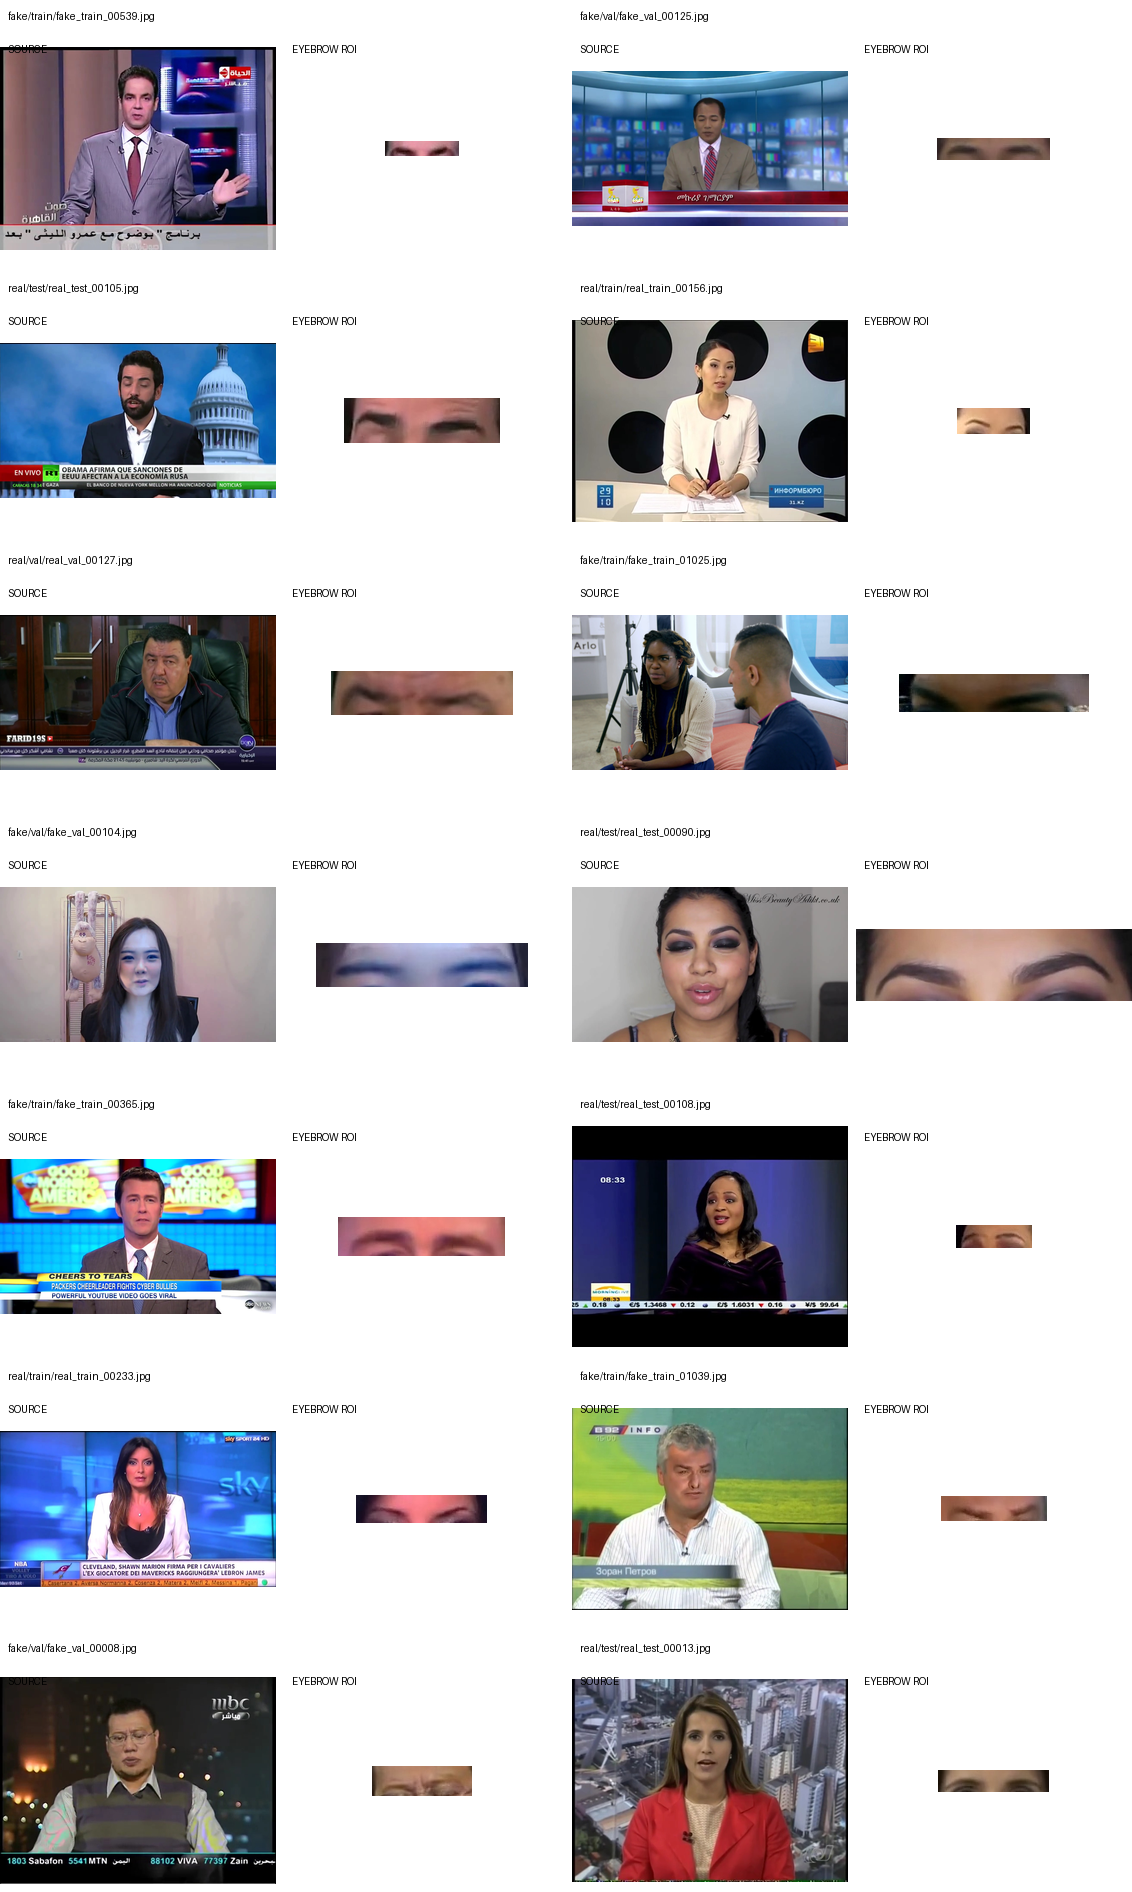


Kaşların ana bölge olduğundan ve gözlerin büyük kısmının crop içinde bulunmadığından emin olun.
Preview uygun değilse config marginlerini değiştirip self-test ve preview hücrelerini yeniden çalıştırın.


In [8]:
# 8) DRY RUN / PREVIEW
# Ana kaş crop'ları bu hücrede kaydedilmez.
# Yalnızca TARGET_ROOT/preview_grid.png üretilir.

if not SELF_TESTS_PASSED:
    raise RuntimeError("Self-testler geçmeden preview oluşturulamaz.")

EXTRACTOR = EyebrowROIExtractor(CONFIG)
PREVIEW_BUILDER = PreviewBuilder(CONFIG, PATH_VALIDATOR)

with FaceLandmarkDetector(CONFIG) as preview_detector:
    PREVIEW_RESULT = PREVIEW_BUILDER.build(
        INPUT_PATHS, preview_detector, EXTRACTOR
    )

PREVIEW_CREATED = (
    Path(PREVIEW_RESULT["preview_path"]).is_file()
    and PREVIEW_RESULT["success_count"] > 0
)

print(json.dumps(PREVIEW_RESULT, ensure_ascii=False, indent=2))

from IPython.display import display
display(Image.open(PREVIEW_RESULT["preview_path"]))

print(
    "\nKaşların ana bölge olduğundan ve gözlerin büyük kısmının "
    "crop içinde bulunmadığından emin olun."
)
print(
    "Preview uygun değilse config marginlerini değiştirip "
    "self-test ve preview hücrelerini yeniden çalıştırın."
)

In [9]:
# 9) FULL PIPELINE
# Preview'ı gözle kontrol ettikten sonra aşağıdaki değeri tam olarak
# "I APPROVE FULL PIPELINE" yapın. Varsayılan durumda başlamaz.

FULL_PIPELINE_CONFIRMATION = "I APPROVE FULL PIPELINE"

if not SELF_TESTS_PASSED:
    raise RuntimeError(
        "Self-testler geçmeden full pipeline çalıştırılamaz."
    )
if not globals().get("PREVIEW_CREATED", False):
    raise RuntimeError("Önce DRY RUN / PREVIEW hücresini çalıştırın.")
if FULL_PIPELINE_CONFIRMATION != "I APPROVE FULL PIPELINE":
    raise PermissionError(
        "Full pipeline kilitli. Preview uygunsa "
        'FULL_PIPELINE_CONFIRMATION = "I APPROVE FULL PIPELINE" '
        "olarak değiştirin."
    )

PATH_VALIDATOR.validate()
print("SOURCE:", CONFIG.source_root)
print("TARGET:", CONFIG.target_root)
print(
    "Başka bir Nazlıcan veya Kaş klasörü aranmayacak "
    "ve değiştirilmeyecek."
)

with FaceLandmarkDetector(CONFIG) as full_detector:
    RUNNER = PipelineRunner(
        CONFIG, PATH_VALIDATOR, full_detector
    )
    FULL_SUMMARY = RUNNER.run(INPUT_PATHS)

print(json.dumps(FULL_SUMMARY, ensure_ascii=False, indent=2))


SOURCE ROOT:
"/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame"

TARGET ROOT:
"/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş"

OUTPUT STRUCTURE:
Kaş/
├── fake/
├── real/
├── run_config.json
├── metadata.csv
├── skipped_or_error.csv
├── checkpoint.json
├── summary.json
├── pipeline.log
└── preview_grid.png

Outputs will be written only to the exact TARGET path shown above. No other Nazlıcan or Kaş folder will be searched or modified.

Path güvenlik doğrulaması başarılı.
SOURCE: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame
TARGET: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş
Başka bir Nazlıcan veya Kaş klasörü aranmayacak ve değiştirilmeyecek.


Full eyebrow ROI pipeline:   0%|          | 0/3000 [00:00<?, ?it/s]

2026-08-06 14:29:15,559 | INFO | SUCCESS | /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00000.jpg -> /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/fake/test/fake_test_00000.jpg
2026-08-06 14:29:15,601 | INFO | SUCCESS | /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00001.jpg -> /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/fake/test/fake_test_00001.jpg
2026-08-06 14:29:15,659 | INFO | SUCCESS | /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00002.jpg -> /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/fake/test/fake_test_00002.jpg
2026-08-06 14:29:15,707 | INFO | SUCCESS | /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame/Fake/test/fake_test_00003.jpg -> /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/fa

{
  "run_id": "20260806_142915_eyebrow_roi_seed42_b775dfb93f",
  "completed_at": "2026-08-06T14:45:17.742718+00:00",
  "duration_seconds": 962.251,
  "total_inputs": 3000,
  "success_count": 1962,
  "skipped_count": 1038,
  "error_count": 0,
  "new_success_count": 1962,
  "new_skipped_count": 1038,
  "new_error_count": 0,
  "already_completed_count": 0,
  "retained_skipped_count": 0,
  "retained_error_count": 0,
  "reprocessed_count": 0,
  "source_root": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame",
  "target_root": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş",
  "accounting_assertion": "total_inputs == success_count + skipped_count + error_count"
}


In [10]:
# 10) SONUÇ ÖZETİ

summary_path = CONFIG.target_root / "summary.json"
metadata_path = CONFIG.target_root / "metadata.csv"
skipped_path = CONFIG.target_root / "skipped_or_error.csv"

if not summary_path.is_file():
    print(
        "summary.json henüz yok. Full pipeline tamamlandıktan "
        "sonra tekrar çalıştırın."
    )
else:
    summary = json.loads(
        summary_path.read_text(encoding="utf-8")
    )
    print(json.dumps(summary, ensure_ascii=False, indent=2))

    metadata = pd.read_csv(
        metadata_path, keep_default_na=False
    )
    display(
        metadata["status"]
        .value_counts(dropna=False)
        .rename_axis("status")
        .reset_index(name="count")
    )

    if skipped_path.is_file():
        failed = pd.read_csv(
            skipped_path, keep_default_na=False
        )
        if not failed.empty:
            display(
                failed[[
                    "input_relative_path", "status", "skip_reason",
                    "error_type", "error_message",
                ]].head(50)
            )

{
  "accounting_assertion": "total_inputs == success_count + skipped_count + error_count",
  "already_completed_count": 0,
  "completed_at": "2026-08-06T14:45:17.742718+00:00",
  "duration_seconds": 962.251,
  "error_count": 0,
  "new_error_count": 0,
  "new_skipped_count": 1038,
  "new_success_count": 1962,
  "reprocessed_count": 0,
  "retained_error_count": 0,
  "retained_skipped_count": 0,
  "run_id": "20260806_142915_eyebrow_roi_seed42_b775dfb93f",
  "skipped_count": 1038,
  "source_root": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Deney 1 Frame",
  "success_count": 1962,
  "target_root": "/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş",
  "total_inputs": 3000
}


,status,count
0,SUCCESS,1962
1,SKIPPED,1038


,input_relative_path,status,skip_reason,error_type,error_message
0,Fake/test/fake_test_00004.jpg,SKIPPED,insufficient_space_below_eyebrows,,
1,Fake/test/fake_test_00006.jpg,SKIPPED,insufficient_space_below_eyebrows,,
2,Fake/test/fake_test_00008.jpg,SKIPPED,insufficient_space_below_eyebrows,,
3,Fake/test/fake_test_00010.jpg,SKIPPED,insufficient_space_below_eyebrows,,
4,Fake/test/fake_test_00012.jpg,SKIPPED,insufficient_space_below_eyebrows,,
5,Fake/test/fake_test_00018.jpg,SKIPPED,roi_height_too_small:13,,
6,Fake/test/fake_test_00021.jpg,SKIPPED,multiple_faces_detected:2,,
7,Fake/test/fake_test_00022.jpg,SKIPPED,face_not_found,,
8,Fake/test/fake_test_00023.jpg,SKIPPED,insufficient_space_below_eyebrows,,
9,Fake/test/fake_test_00028.jpg,SKIPPED,face_not_found,,


In [11]:
# 11) OLUŞTURULAN DOSYALARI GÖSTERME
# Yalnızca kesin TARGET_ROOT listelenir; Drive genelinde arama yoktur.

expected_files = [
    "run_config.json",
    "metadata.csv",
    "skipped_or_error.csv",
    "checkpoint.json",
    "summary.json",
    "pipeline.log",
    "preview_grid.png",
]

print("TARGET ROOT:", CONFIG.target_root)
print("\nAna dosyalar:")
for name in expected_files:
    path = CONFIG.target_root / name
    if path.exists():
        print(f"[OK]  {name:<24} {path.stat().st_size:,} bayt")
    else:
        print(f"[YOK] {name}")

print("\nSınıf/split klasörleri:")
for label in ("fake", "real"):
    for split in ("train", "val", "test"):
        split_path = CONFIG.target_root / label / split
        if split_path.is_dir():
            count = sum(
                1
                for path in split_path.rglob("*")
                if path.is_file()
                and path.suffix.lower()
                in CONFIG.image_extensions
            )
            print(f"[OK]  {label}/{split}: {count:,} crop")
        else:
            print(f"[YOK] {label}/{split}")

TARGET ROOT: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş

Ana dosyalar:
[OK]  run_config.json          2,126 bayt
[OK]  metadata.csv             1,869,438 bayt
[OK]  skipped_or_error.csv     596,252 bayt
[OK]  checkpoint.json          805 bayt
[OK]  summary.json             732 bayt
[OK]  pipeline.log             723,625 bayt
[OK]  preview_grid.png         1,215,391 bayt

Sınıf/split klasörleri:
[OK]  fake/train: 776 crop
[OK]  fake/val: 98 crop
[OK]  fake/test: 95 crop
[OK]  real/train: 786 crop
[OK]  real/val: 106 crop
[OK]  real/test: 101 crop
